In [97]:
%pip install mediapipe opencv-python scikit-learn torch pandas

Note: you may need to restart the kernel to use updated packages.


In [98]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [99]:
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [100]:
class Model(nn.Module):
    def __init__(self, in_features=180, h1=128, h2=128, h3=64, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.out = nn.Linear(h3, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        x = self.out(x)
        return x

In [101]:
path = '../data.csv'
df = pd.read_csv(path, header=None, names=['type', 'name', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4'])
df = df.drop('name', axis=1)
df

n = 15  # rows per sequence
num_groups = df.shape[0] // n

def make_relative_per_landmark(group):
    for i in range(1, 5):
        x_col, y_col, z_col = f'x{i}', f'y{i}', f'z{i}'
        x0, y0, z0 = group.iloc[0][[x_col, y_col, z_col]]
        group[x_col] = group[x_col] - x0
        group[y_col] = group[y_col] - y0
        group[z_col] = group[z_col] - z0
    coords_array = group[[f'x{i}' for i in range(1, 5)] + [f'y{i}' for i in range(1, 5)] + [f'z{i}' for i in range(1, 5)]].to_numpy()
    coords_reshaped = coords_array.reshape(len(group), 4, 3)

    group[[f'x{i}' for i in range(1, 5)] + [f'y{i}' for i in range(1, 5)] + [f'z{i}' for i in range(1, 5)]] = coords_reshaped.reshape(len(group), 12)

    return group

groups = [make_relative_per_landmark(df.iloc[i*n:(i+1)*n].copy()) for i in range(num_groups)]
df_rel = pd.concat(groups, ignore_index=True)

df = df_rel

df

,type,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4
0,uppercut_left,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,uppercut_left,0.000800,0.045253,-0.269514,0.002325,0.003170,-0.224746,-0.000102,0.001780,-0.095475,-0.000160,0.000090,-0.162670
2,uppercut_left,0.001225,0.131184,-0.129621,0.004572,0.007173,-0.256297,-0.004822,0.008894,-0.004818,-0.001362,0.001654,-0.205581
3,uppercut_left,0.026370,0.172625,-0.059274,0.009934,0.013567,-0.309170,-0.009824,0.018615,0.080975,-0.001879,0.004682,-0.243685
4,uppercut_left,0.046013,0.204017,-0.020334,0.014610,0.018864,-0.341123,-0.009747,0.023997,0.115841,-0.001880,0.010535,-0.260017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,uppercut_right,-0.002198,0.013147,-0.060112,0.056663,0.054851,0.034268,0.000728,-0.000320,-0.037143,0.016943,0.019744,-0.018710
1316,uppercut_right,-0.002185,0.011901,0.049407,0.019224,-0.008640,0.022998,0.002452,-0.000121,0.004836,0.005214,-0.019858,0.037244
1317,uppercut_right,-0.002192,0.006223,0.024824,-0.002668,-0.004395,0.004833,0.003051,-0.000118,-0.008893,-0.004516,0.005071,0.004976
1318,uppercut_right,-0.001129,-0.005226,-0.097431,-0.006848,0.030367,-0.062561,0.003045,-0.000109,-0.053310,-0.002193,0.024498,-0.012087


In [102]:
df['type'] = df['type'].replace('hook_left', 'hook')
df['type'] = df['type'].replace('hook_right', 'hook')
df['type'] = df['type'].replace('jab_left', 'jab')
df['type'] = df['type'].replace('jab_right', 'jab')
df['type'] = df['type'].replace('uppercut_left', 'uppercut')
df['type'] = df['type'].replace('uppercut_right', 'uppercut')
type_mapping = {'hook': 0, 'jab': 1, 'uppercut': 2}
df['type'] = df['type'].map(type_mapping)

X = np.array(df.drop('type', axis=1))
y = np.array(df['type'])

In [103]:
features = ['x1','y1', 'z1','x2','y2', 'z2','x3','y3','z3','x4','y4','z4']

n = 15
num_groups = df.shape[0] // n

# Trim the DataFrame to a multiple of n
df_trim = df.iloc[:num_groups * n]

# Convert to NumPy array (only features)
arr = df_trim[features].values  # shape: (num_groups * n, 12)

# Reshape into sequences of 15 rows
grouped = arr.reshape(num_groups, n, len(features))  # shape: (num_groups, 15, 12)

# Flatten each sequence into a single vector
X = grouped.reshape(num_groups, -1)  # shape: (num_groups, 15*12=180)

# Handle labels (assume df['type'] is the label)
y_arr = df_trim['type'].values
y = y_arr.reshape(num_groups, n)[:, 0]  # take first row's label for each sequence

print("X shape:", X.shape)  # should be (num_groups, 180)
print("y shape:", y.shape)  # should be (num_groups,)

X shape: (88, 180)
y shape: (88,)


In [104]:
torch.manual_seed(42)
model = Model()
model

Model(
  (fc1): Linear(in_features=180, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=3, bias=True)
)

In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.33, random_state=42)

In [106]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_val = torch.FloatTensor(X_val)

# convert y labels to long tensors (64-bit integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)
y_val = torch.LongTensor(y_val)

In [107]:
# set criterion of model to measure error (how far off predictions are from data)
criterion = nn.CrossEntropyLoss()

# choose Adam Optimizer
# lr = learning rate (if error doesn't go down after a bunch of epochs, must lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [108]:
# train our model
# epoch = one run through all training data in our network
epochs = 200
losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
  # go forward & get a prediction
  y_pred = model.forward(X_train) # get predicted results

  # measure loss/error, will be high at first
  loss = criterion(y_pred, y_train); # predicted vs training y

  # keep track of losses
  losses.append(loss.detach().numpy())
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  with torch.no_grad():
    train_outputs = model(X_train)
    train_preds = torch.argmax(train_outputs, dim=1)
    train_accuracy = (train_preds == y_train).float().mean().item()
    train_accuracies.append(train_accuracy)

    val_outputs = model(X_val)
    val_preds = torch.argmax(val_outputs, dim=1)
    val_accuracy = (val_preds == y_val).float().mean().item()
    val_accuracies.append(val_accuracy)

  print(f"Epoch {i+1}/{epochs}, Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")

Epoch: 0 and loss: 1.1187478303909302
Epoch 1/200, Train Accuracy: 0.3409, Val Accuracy: 0.4000
Epoch 2/200, Train Accuracy: 0.3409, Val Accuracy: 0.4000
Epoch 3/200, Train Accuracy: 0.3409, Val Accuracy: 0.4000
Epoch 4/200, Train Accuracy: 0.3409, Val Accuracy: 0.4000
Epoch 5/200, Train Accuracy: 0.3864, Val Accuracy: 0.4000
Epoch 6/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 7/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 8/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 9/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 10/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch: 10 and loss: 1.0682704448699951
Epoch 11/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 12/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 13/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 14/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 15/200, Train Accuracy: 0.3864, Val Accuracy: 0.3333
Epoch 16/200, Train Accuracy: 0.4091, Val Accur

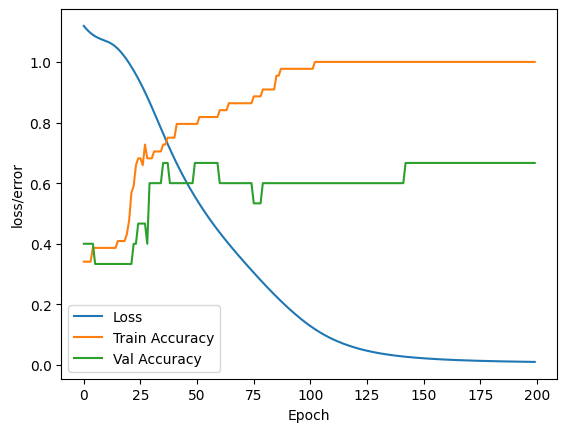

In [109]:
# plot the losses
plt.plot(range(epochs), losses)
plt.plot(range(epochs), train_accuracies)
plt.plot(range(epochs), val_accuracies)
plt.ylabel("loss/error")
plt.xlabel("Epoch")
plt.legend(["Loss", "Train Accuracy", "Val Accuracy"])

In [110]:
train_accuracies = []
val_accuracies = []

# evaluate model on test data
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)
loss

tensor(1.2884)

In [111]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "hook"
    elif y_test[i] == 1:
      x = "uppercut"
    elif y_test[i] == 2:
      x = "jab"

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} out of {len(X_test)} correct.')

1.) tensor([-1.9512, -1.7583,  3.2810]) 	 2 	 2
2.) tensor([-1.9929,  3.8977, -2.5817]) 	 1 	 1
3.) tensor([ 0.0923, -1.0334,  0.7088]) 	 1 	 2
4.) tensor([ 2.0511, -1.5565, -0.5236]) 	 1 	 0
5.) tensor([-1.2795, -1.6257,  2.5074]) 	 0 	 2
6.) tensor([ 4.0129, -1.6823, -1.9823]) 	 0 	 0
7.) tensor([ 4.5313, -1.6730, -2.2649]) 	 2 	 0
8.) tensor([-1.9392,  4.0368, -2.7327]) 	 1 	 1
9.) tensor([-2.5011,  0.2076,  1.4991]) 	 0 	 2
10.) tensor([ 3.6371, -1.7177, -1.6773]) 	 0 	 0
11.) tensor([ 2.1902,  1.0044, -3.7916]) 	 1 	 0
12.) tensor([-1.4794,  3.1852, -2.4060]) 	 1 	 1
13.) tensor([ 3.8101, -1.1068, -2.4584]) 	 0 	 0
14.) tensor([-1.8275, -2.3533,  4.1233]) 	 2 	 2
15.) tensor([-1.7948,  3.9400, -2.8024]) 	 1 	 1
16.) tensor([ 2.0099, -0.3862, -1.6625]) 	 0 	 0
17.) tensor([ 4.3733, -2.0222, -1.8903]) 	 0 	 0
18.) tensor([ 3.7725, -2.4612, -1.1223]) 	 0 	 0
19.) tensor([ 0.0980, -1.0110,  0.6876]) 	 0 	 2
20.) tensor([-2.0790, -2.2489,  4.0617]) 	 2 	 2
21.) tensor([-2.2130, -2.1468

In [112]:
torch.save(model.state_dict(), "model_state.pt")